# Entrainement de modèles de classification textuelle

Nous allons voir aujourd'hui comment entrainer des classifieurs textuels, en utilisant des embeddings de mots pour représenter le contenu d'un texte, avec trois méthodes différentes:

1. A partir de représentations
précalculées (statiques comme word2vec, glove).
3. En fine-tunant des modèles contextuels pré-entrainés (type Bert/GPT).
3. En prompting/in-context learning avec un (petit) modèle génératif

Nous prendrons comme exemple de tâches la classification de sentiments, avec le jeu de données IMDB https://huggingface.co/datasets/stanfordnlp/imdb
  </p>
</div>


# 1. A partir d'embeddings statiques précalculés






On part d'embeddings pré-calculés, ici glove, pour simplifier : un vecteur est fourni pour chaque token du vocabulaire.
On pourrait aussi utiliser un *text embedding model*, MistralAI embeddings par exemple, qui peut prendre un texte en entrée et fournit sa représentation

(cf d'autres exemples de possibilités sur https://docs.langchain.com/oss/javascript/integrations/text_embedding)

In [1]:
%pip -q install gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gensim
from tqdm import tqdm

In [3]:
# small glove
import gensim.downloader as api
model = api.load("glove-wiki-gigaword-100") #50, 100, 200, 300

In [4]:
vocabulary = model.key_to_index
print(len(vocabulary))

400000


In [5]:
import numpy as np
import string
punct_remove = str.maketrans('', '',string.punctuation)

In [6]:
# exemple de fonction d'encodage de phrase = moyenne des embeddings des mots
def encode(sentence,model):
  vocabulary = set(model.key_to_index)
  words = sentence.lower().translate(punct_remove)
  words = words.split()
  vector = model[[word for word in words if word in vocabulary]].mean(axis=0)
  return vector


In [7]:
%timeit encode("This is a very short test.",model)

16.6 ms ± 555 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Le jeu de données

On va considérer l'analyse de "sentiment", sur des critiques de films issus du site IMDB.

https://huggingface.co/datasets/stanfordnlp/imdb





In [8]:
# lib Huggingface qui définit le format des jeux de données utilisables par la lib transformers
%pip -q install datasets

Note: you may need to restart the kernel to use updated packages.


In [9]:
from datasets import load_dataset
import pandas as pds

In [10]:
# on va seulement entrainer/tester sur une partie du train pour aller plus vite
ds = load_dataset("imdb",split="train")
# on ne touche pas au "vrai" test
ds = ds.train_test_split(train_size=0.04,test_size=0.02)
dataset_train = ds["train"]
dataset_test = ds["test"]

In [11]:
# regardez ce qui est contenu dans les instances
dataset_train[0]

{'text': 'Apparently, this is what happens when a director allows his 14-year old nephew to rewrite the dialogue on the set while he indulges himself alcoholically in the meantime; as I said earlier, although I\'ve always wanted to catch one of Paul Naschy\'s werewolf pictures, this atrocity served as my introduction and, as awful as it most certainly is, I still intend to pursue other entries in the series, albeit very gradually.<br /><br />Despite some high profile disappointments like Joe Dante\'s THE HOWLING (1981), I love werewolf pictures in general but, to be honest, I quickly lost interest in this film\'s "plot" and just stood there gazing at my TV screen counting its absurdities as it were. There were far too many to mention them here but I have to say two which struck me as particularly hilarious were the schizophrenic nature of the Werewolf persona (i.e. going from a raging beast in one shot to a dazed, zombie-like state in the very next one - as if he\'s on a casual midnigh

## Encodage des données

Il faut maintenant encoder les instances du jeu de données pour avoir un ensemble de vecteurs des phrases, et les labels associés

**Ecrire la fonction suivante qui doit renvoyer 2 listes (ou vecteurs): 1) de vecteur des phrases 2) des labels correspondants**

In [12]:
# doit retourner une liste de vecteurs, et une liste de labels correspondants
# correction
def encode_train(instances,model):
  vectors = []
  labels = []
  for instance in tqdm(instances):
    vectors.append(encode(instance["text"],model))
    labels.append(instance["label"])
  return vectors, labels

In [13]:
X, y = encode_train(dataset_train,model)

100%|██████████| 1000/1000 [00:17<00:00, 56.65it/s]


## Entraînement d'un modèle simple

**Vous pouvez maintenant essayer d'entrainer un modèle simple, par exemple une régression logistique ou un MLP avec la librairie scikit-learn, et les évaluer sur les sous-ensembles train et test**


https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html


https://scikit-learn.org/1.5/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier

In [ ]:
# A REMETTRE DANS LE SUJET
# Entrainement
# from sklearn.linear_model import LogisticRegression
# from sklearn.neural_network import MLPClassifier

# # logistic regression
# # clf = ...
# print("accuracy train régression logistique:",clf.score(X,y))
# # MLP
# # clf = ...
# print("accuracy train MLP:",clf.score(X,y))

In [14]:
# Correction
# Entrainement
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# overfit ?
clf = LogisticRegression(random_state=1, max_iter=1000).fit(X, y)
print("accuracy train régression logistique:",clf.score(X,y))
#overfit ++ ?
clf = MLPClassifier().fit(X, y)
print("accuracy train MLP:",clf.score(X,y))

accuracy train régression logistique: 0.796
accuracy train MLP: 0.838


/Users/asriel/miniconda3/envs/LLMs/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
X_val, y_val = encode_train(dataset_test,model)
y_predicted_val = clf.predict(X_val)

# Evaluate the model's performance on the validation set.
print("\n accuracy test MLP:",clf.score(X_val,y_val))

100%|██████████| 500/500 [00:08<00:00, 57.76it/s]


 accuracy test MLP: 0.79


# 2. Fine-tuning d'un modèle contextuel préentrainé

Cette fois on va juste continuer l'entrainement d'un modèle préentrainé, sur nos données spécifiques, en utilisant une librairie dédiée, huggingface, qui gère tout depuis la tokenization, entrainement et prédiction.

**Dans cette partie tout le code est déjà fonctionnel (sauf pour faire les prédictions sur le test), mais vous devez trouver les meilleurs choix de paramètres**

In [16]:
%pip -q install evaluate

Note: you may need to restart the kernel to use updated packages.


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [18]:
import transformers
import evaluate
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import AutoModelForTokenClassification

In [19]:
# sur colab, bien choisir un GPU/TPU dans le runtime ("Execution/modifier le type d'execution")
device = torch.device("mps" if torch.mps.is_available() else "cpu")

In [20]:
# plus prudent avec un petit modele, mais vous pouvez essayer avec bert-base-uncased aussi
base_model = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(base_model)
model = AutoModelForSequenceClassification.from_pretrained(base_model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Différentes options peuvent être testées pour la tokenization.
**Regardez la doc du tokenizer pour éventuellement changer la stratégie de padding et de troncation, et dites si vous voyez des changements de résultats expérimentaux**

In [21]:
# c'est ici qu'on définit ce qui sera effectivement passé en entrée du modèle à partir des instances du dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_train_datasets = dataset_train.map(tokenize_function, batched=True)
tokenized_test_datasets = dataset_test.map(tokenize_function, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Huggingface permet de définir une boucle d'entrainement à partir de certains paramètres de configuration.

Voici une base, **vous pouvez chercher des réglages différents**

https://huggingface.co/docs/transformers/main_classes/trainer



In [22]:
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(output_dir="test_trainer",
                                  #no_cuda=False, # True sur ordi perso sans bon GPU
                                  per_device_train_batch_size=8,
                                  eval_strategy="epoch",
                                  report_to="none",
                                  num_train_epochs=1)

In [23]:
# définition de la métrique d'éval
# NE RIEN MODIFIER ICI

# necessary for evaluation during training
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_datasets,
    eval_dataset=tokenized_test_datasets,
    compute_metrics=compute_metrics,
)

In [25]:
# necessary on colab -> NE RIEN MODIFIER ICI
# Tell the Trainer to not pin memory / caused by having the data already on GPU
training_args.dataloader_pin_memory = False

res = trainer.train()
print(res)

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.305140,0.872000


TrainOutput(global_step=125, training_loss=0.435740478515625, metrics={'train_runtime': 76.0231, 'train_samples_per_second': 13.154, 'train_steps_per_second': 1.644, 'total_flos': 132467398656000.0, 'train_loss': 0.435740478515625, 'epoch': 1.0})


In [26]:
# test predictions sur un exemple
inputs = tokenizer("This movie was so bad it was almost good.", return_tensors="pt").to(device)
outputs = model(**inputs)
# get the normalized scores
list(nn.Softmax(dim=1)(outputs.logits).detach().cpu().numpy()[0])

[np.float32(0.95849454), np.float32(0.0415055)]

In [27]:
# get the most likely class
np.argmax(outputs.logits.detach().cpu(),axis=-1)

tensor([0])

On peut regarder les prédictions du modèles, et les scores assignées à chaque classe pour chaque instance:

In [28]:
input_test = tokenized_test_datasets
predictions = trainer.predict(input_test)

In [29]:
predictions.metrics

{'test_loss': 0.3051397502422333,
 'test_accuracy': 0.872,
 'test_runtime': 7.7761,
 'test_samples_per_second': 64.299,
 'test_steps_per_second': 8.102}

In [30]:
predictions.predictions.shape

(500, 2)

In [31]:
torch_logits = torch.from_numpy(predictions.predictions)
probabilities_scores = F.softmax(torch_logits,dim=1).numpy()

(array([[173.,  35.,  14.,   6.,   5.,   4.,   4.,   7.,   2.,   5.,   5.,
           5.,   7.,   3.,   8.,   4.,   8.,  16.,  13., 176.],
        [176.,  13.,  16.,   8.,   4.,   8.,   3.,   7.,   5.,   5.,   5.,
           2.,   7.,   4.,   4.,   5.,   6.,  14.,  35., 173.]]),
 array([0.02663493, 0.07397144, 0.12130795, 0.16864446, 0.21598096,
        0.26331747, 0.31065398, 0.35799047, 0.40532699, 0.45266351,
        0.5       , 0.54733652, 0.59467304, 0.64200956, 0.68934602,
        0.73668253, 0.78401905, 0.83135557, 0.87869209, 0.92602855,
        0.97336507]),
 <a list of 2 BarContainer objects>)

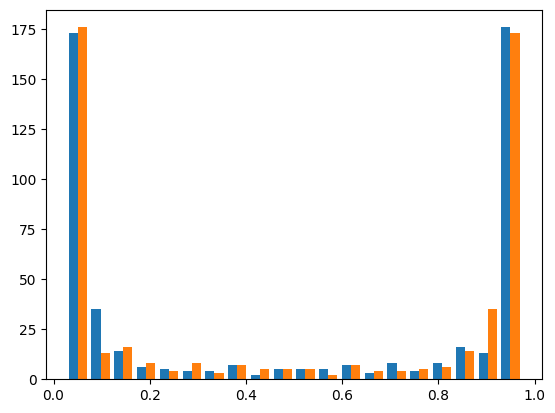

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.hist(probabilities_scores,20)

**Que peut-on dire des probablités des prédictions du modèle ?**

# 3. Utiliser des méthodes PEFT

Fine-tunez un modèle plus large, par exemple BERT, mais en utilisant la méthode LoRA pour réduire le nombre de paramètres à entraîner.

Afficher les couches ainsi que leur taille, avant et après avoir appliqué LoRA.



LoRA doc: https://huggingface.co/docs/peft/package_reference/lora

Etapes:
* load le modèle distilBERT
* afficher le modèle pour voir le nom donné aux modules (on applique LoRA aux modules : key, query, value ; le reste est frozen)
* définir la config LoRA
* récupérer le modèle LoRA à partir du modèle DistilBERT et de la config
* afficher les couches ainsi que leur taille, avant et après avoir appliqué LoRA
* on garde les même training_args qu'avant
* entraîner puis afficher l'accuracy sur le test
* afficher le nombre de trainable parameters du modèle LoRA
* tester 2 valeurs différentes pour le rang des matrices LoRA : quelles différences ?


In [34]:
from peft import LoraModel, LoraConfig, get_peft_model

### LoRA sur distilBERT (pour comparaison)

In [33]:
# correction
# load le modèle DistilBERT
base_model = "distilbert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(base_model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [35]:
# correction
# afficher le modèles : quels noms pour les paramètres k,q,v ?
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [36]:
# correction
# définir la config LoRA
config = LoraConfig(
    r=8, # Lora attention dimension (the “rank”).
    lora_alpha=32, # The alpha parameter for Lora scaling.
    target_modules = ["k_lin", "q_lin", "v_lin"], # The names of the modules to apply the adapter to.
    lora_dropout=0.01, # The dropout probability for Lora layers.
    modules_to_save=["classifier"], #  List of modules apart from adapter layers to be set as trainable and saved in the final checkpoint.
)

In [37]:
# correction
# Récupérer le modèle Lora et définir le Trainer
lora_model = get_peft_model(model, config)

lora_trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_train_datasets,
    eval_dataset=tokenized_test_datasets,
    compute_metrics=compute_metrics,
)

In [38]:
# correction
# Lancer l'entraînement
# necessary on colab -> NE RIEN MODIFIER ICI
# Tell the Trainer to not pin memory / caused by having the data already on GPU
training_args.dataloader_pin_memory = False

res = lora_trainer.train()
print(res)

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.646313,0.736000


TrainOutput(global_step=125, training_loss=0.670343505859375, metrics={'train_runtime': 64.3117, 'train_samples_per_second': 15.549, 'train_steps_per_second': 1.944, 'total_flos': 134965899264000.0, 'train_loss': 0.670343505859375, 'epoch': 1.0})


In [39]:
# correction
# Afficher l'accuracy sur le test
input_test = tokenized_test_datasets
predictions = lora_trainer.predict(input_test)
predictions.metrics

{'test_loss': 0.6463132500648499,
 'test_accuracy': 0.736,
 'test_runtime': 8.7709,
 'test_samples_per_second': 57.007,
 'test_steps_per_second': 7.183}

In [40]:
# correction
# Afficher le nombre de paramètres entrainable
lora_model.print_trainable_parameters()

trainable params: 813,314 || all params: 67,768,324 || trainable%: 1.2001


In [41]:
# Permet de relancer un LoRA : tester 2 valeurs, quelles différences ?
lora_model.unload() # type: ignore
del lora_model
torch.mps.empty_cache() 

#### correction

Comparison

- LoRA 8:   acc ; runtime  ; trainable 1.2%
- LoRA 16:  acc ; runtime  ; trainable 1.5%
- LoRA 32:  acc ..

### LoRA on BERT

In [42]:
# correction
base_model = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(base_model)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
# correction
# ne pas oublier de tokenizer ;)
tokenizer = AutoTokenizer.from_pretrained(base_model)
# c'est ici qu'on définit ce qui sera effectivement passé en entrée du modèle à partir des instances du dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_train_datasets = dataset_train.map(tokenize_function, batched=True)
tokenized_test_datasets = dataset_test.map(tokenize_function, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [44]:
from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(output_dir="test_trainer",
                                  #no_cuda=False, # True sur ordi perso sans bon GPU
                                  per_device_train_batch_size=8,
                                  eval_strategy="epoch",
                                  report_to="none",
                                  num_train_epochs=1)

In [45]:
# définition de la métrique d'éval
# NE RIEN MODIFIER ICI

# necessary for evaluation during training
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [46]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_datasets,
    eval_dataset=tokenized_test_datasets,
    compute_metrics=compute_metrics,
)

In [47]:
# necessary on colab -> NE RIEN MODIFIER ICI
# Tell the Trainer to not pin memory / caused by having the data already on GPU
training_args.dataloader_pin_memory = False

res = trainer.train()
print(res)

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.270592,0.892000


TrainOutput(global_step=125, training_loss=0.4653212585449219, metrics={'train_runtime': 152.5725, 'train_samples_per_second': 6.554, 'train_steps_per_second': 0.819, 'total_flos': 263111055360000.0, 'train_loss': 0.4653212585449219, 'epoch': 1.0})


In [72]:
input_test = tokenized_test_datasets
predictions = trainer.predict(input_test)

In [73]:
predictions.metrics

{'test_loss': 0.34277984499931335,
 'test_accuracy': 0.89,
 'test_runtime': 8.6941,
 'test_samples_per_second': 57.51,
 'test_steps_per_second': 7.246}

- Full BERT : 80.8 acc ; 121 runtime ;

In [74]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [75]:
# correction
config = LoraConfig(
    r=16, # Lora attention dimension (the “rank”).
    lora_alpha=32, # The alpha parameter for Lora scaling.
    target_modules = ["key", "query", "value"], # The names of the modules to apply the adapter to.
    lora_dropout=0.01, # The dropout probability for Lora layers.
    modules_to_save=["classifier"], #  List of modules apart from adapter layers to be set as trainable and saved in the final checkpoint.
)

In [76]:
# correction
lora_model = get_peft_model(model, config)

lora_trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_train_datasets,
    eval_dataset=tokenized_test_datasets,
    compute_metrics=compute_metrics,
)

In [ ]:
# correction
for layer_name, params in model.named_parameters():
    print(layer_name, params.shape)

In [ ]:
# correction

for layer_name, params in lora_model.named_parameters():
    print(layer_name, params.shape)

In [79]:
# necessary on colab -> NE RIEN MODIFIER ICI
# Tell the Trainer to not pin memory / caused by having the data already on GPU
training_args.dataloader_pin_memory = False

res = lora_trainer.train()
print(res)

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.361820,0.896000


TrainOutput(global_step=125, training_loss=0.16160990905761718, metrics={'train_runtime': 70.6567, 'train_samples_per_second': 14.153, 'train_steps_per_second': 1.769, 'total_flos': 265833689088000.0, 'train_loss': 0.16160990905761718, 'epoch': 1.0})


In [80]:
input_test = tokenized_test_datasets
predictions = lora_trainer.predict(input_test)
predictions.metrics

{'test_loss': 0.3618195056915283,
 'test_accuracy': 0.896,
 'test_runtime': 9.6738,
 'test_samples_per_second': 51.686,
 'test_steps_per_second': 6.512}

In [81]:
lora_model.print_trainable_parameters()

trainable params: 886,274 || all params: 110,370,052 || trainable%: 0.8030


In [82]:
lora_model.unload() # type: ignore
del lora_model
torch.mps.empty_cache()

- LoRA 16 :  acc  ; runtime  ; trainable % 0.840
- LoRA 64 :  acc

### !! Test du LoRA BERT sans FT initial, ONLY LoRA


In [ ]:
# correction
base_model = "bert-base-uncased"
model_t = AutoModelForSequenceClassification.from_pretrained(base_model)

In [ ]:
# correction
# ne pas oublier de tokenizer ;)
tokenizer = AutoTokenizer.from_pretrained(base_model)
# c'est ici qu'on définit ce qui sera effectivement passé en entrée du modèle à partir des instances du dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_train_datasets = dataset_train.map(tokenize_function, batched=True)
tokenized_test_datasets = dataset_test.map(tokenize_function, batched=True)

In [ ]:
# correction
config = LoraConfig(
    r=16, # Lora attention dimension (the “rank”).
    lora_alpha=32, # The alpha parameter for Lora scaling.
    target_modules = ["key", "query", "value","dense"], # The names of the modules to apply the adapter to.
    lora_dropout=0.01, # The dropout probability for Lora layers.
    modules_to_save=["classifier"], #  List of modules apart from adapter layers to be set as trainable and saved in the final checkpoint.
)

In [ ]:
# correction
lora_model = get_peft_model(model_t, config)

lora_trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_train_datasets,
    eval_dataset=tokenized_test_datasets,
    compute_metrics=compute_metrics,
)

In [ ]:
# necessary on colab -> NE RIEN MODIFIER ICI
# Tell the Trainer to not pin memory / caused by having the data already on GPU
training_args.dataloader_pin_memory = False

res = lora_trainer.train()
print(res)

In [ ]:
input_test = tokenized_test_datasets
predictions = lora_trainer.predict(input_test)
predictions.metrics

In [ ]:
lora_model.print_trainable_parameters()

In [ ]:
lora_model

### LoRA on xlm-RoBERTa Large ?

In [ ]:
# correction
base_model = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(base_model)

In [ ]:
model

# 4. "Petits" modèles génératifs pour de la classification

On va tester des modèles génératifs sur la même tâche de classification.
Comme on n'a pas le temps ni les ressources pour des gros modèles, pour lesquels les auteurs rapportent de bonnes performances sur cette tâche, on va s'intéresser à des petits modèles et voir si ça marche aussi !

Un "petit" modèle est soit conçu petit (e.g. Smoll de HuggingFace) soit c'est un grand modèle distribué en version petite (e.g. quantizé).



## Zero shot with des petits modèles génératifs

Zero‑shot et k‑shot en quelques mots

__Zero‑shot__ : fournir au modèlele texte à classer et la liste des labels possibles (sous forme de phrases ou de mots), et il infère directement la bonne classe par compréhension sémantique, sans ré‑entraînement sur ta tâche.
​

__K‑shot__ : ajouter quelques exemples annotés par classe dans le prompt (ou via un léger fine‑tuning) pour guider le modèle, ce qui améliore souvent les performances sur des tâches spécialisées

  - On peut aussi utiliser la librairie transformers pour appeler des modèles génératifs, et tenter de la classification en 0-shot (ou k-shot).

 - On peut utiliser une "pipeline" de transformers, avec l'option ici qu'on fait du text-to-text.

In [ ]:
from transformers import pipeline

pipeline = pipeline(
    task="text2text-generation",
    model="google-t5/t5-base",
    dtype=torch.float16,
    device=0
)
output = pipeline("translate English to French: The weather is nice today.")

In [ ]:
output

In [ ]:
#On peut reprendre les données imdb pour les insérer dans un prompt
instance = dataset_train[0]["text"]
print(instance)
print(dataset_train[0]["label"])

In [ ]:
prompt = "Classify the text as negative or positive. Text:"+instance+" Sentiment:" # à vous
output = pipeline(prompt)
output

In [ ]:
prompt = "Sentiment analysis : You have to indicate the sentiment of the text, the options are: negative or positive. Text:"+instance+" Sentiment:" # à vous
output = pipeline(prompt)
output

In [ ]:
prompt = "Sentiment analysis: A text can be either negative (0) or positive (1). You have to indicate the sentiment of the following text. Text:"+instance+" Sentiment:" # à vous
output = pipeline(prompt)
output

In [ ]:
prompt = "Sentiment analysis: Example:\ninput_text: sst2 sentence: This movie is awesome.\nPrediction: positive\ninput_text: sst2 sentence: "+instance+"\nPrediction:" # à vous
output = pipeline(prompt)
output

In [ ]:
instance_pos = "This movie is bad"
prompt = "Sentiment analysis : You have to indicate the sentiment of the text, the options are: negative or positive. Text:"+instance_pos+" Sentiment:" # à vous
output = pipeline(prompt)
output

On peut faire aussi plus bas niveau en appelant le modèle directement en récupérant les sorties (incluant les scores)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
model = AutoModelForCausalLM.from_pretrained("crumb/nano-mistral")
tokenizer = AutoTokenizer.from_pretrained("crumb/nano-mistral")

inputs = tokenizer([prompt], return_tensors="pt")
print(inputs)
outputs = model.generate(**inputs, max_new_tokens=128, temperature=0.7, top_k=40, do_sample=True)
outputs = tokenizer.batch_decode(outputs)

### Fine-tuning a generative model (XX enlever ?)

From https://www.projectpro.io/article/llm-sentiment-analysis/1125#mcetoc_1iptv4qqvo

In [48]:
%%capture
%pip install -q transformers datasets peft accelerate bitsandbytes

In [50]:
%pip -q install -U bitsandbytes

Note: you may need to restart the kernel to use updated packages.


In [51]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from transformers import BitsAndBytesConfig, DataCollatorForLanguageModeling

In [52]:
model_id = "mistralai/Mistral-7B-Instruct-v0.1"

In [53]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

In [ ]:
model = prepare_model_for_kbit_training(base_model)

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

In [ ]:
# Small example dataset

train_data = [
    {"text": "Review: I love this product! Sentiment: Positive"},
    {"text": "Review: This is the worst purchase I've made. Sentiment: Negative"},
    {"text": "Review: It works okay, not too bad. Sentiment: Neutral"},
    {"text": "Review: Absolutely amazing experience! Sentiment: Positive"}
]

from datasets import Dataset

dataset = Dataset.from_list(train_data)

# Tokenize

MAX_LENGTH = 512

def tokenize_function(example):
    result = tokenizer(example["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)
    result["labels"] = result["input_ids"].copy()
    return result

tokenized_dataset = dataset.map(tokenize_function)

In [ ]:
training_args = TrainingArguments(
    output_dir="./llm-sentiment",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    logging_dir="./logs",
    report_to=[],
    fp16=True,
    optim="paged_adamw_8bit"
)
collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=collator
)

trainer.train()

In [ ]:
def infer(prompt):
    input_text = f"Review: {prompt} Sentiment:"
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=20)
    print(tokenizer.decode(output[0], skip_special_tokens=True))

infer("I really liked this phone, great battery life")
infer("The camera quality is terrible and it's very slow")